In [1]:
import numpy as np
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('spam.csv', encoding='latin')

In [ ]:
#Hacemos el sanity check de todos los días 

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [ ]:
#Vemos el porcentaje de nulos que hay en cada columna
for i in range(2,5):
    print("Porcentaje de nulos en Unnamed 2 es ", str(df[f'Unnamed: {i}'].isnull().sum()/len(df)))

Porcentaje de nulos en Unnamed 2 es  0.9910265613783201
Porcentaje de nulos en Unnamed 2 es  0.9978463747307968
Porcentaje de nulos en Unnamed 2 es  0.9989231873653984


Un 99% no nos da apenas info así lo mejor que podemos hacer es simplemente eliminarlos

In [15]:
columns = ['Unnamed: 2','Unnamed: 3', 'Unnamed: 4']

df = df.drop(columns, axis=1)

In [ ]:
#Vemos que se haya hecho bien, si solo hicieramos df.drop no hubiese eliminado nada, habria que usar inplace

df

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


En porcentaje los porcentajes de cada uno son v1
ham     0.865937
spam    0.134063
Name: count, dtype: float64


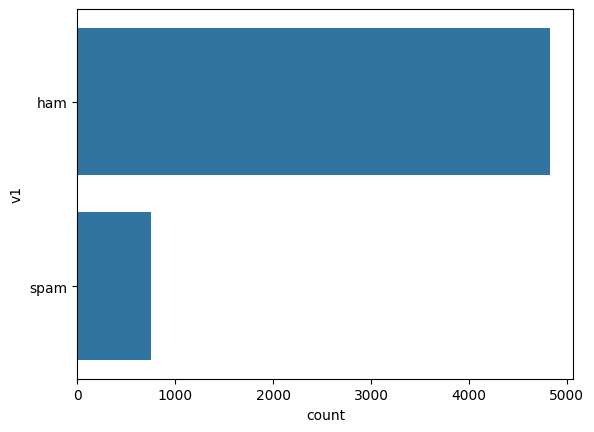

In [22]:
#Podemos ver como esta distribuido la variable v1

sns.countplot(df.v1)

#Vemos tambien en numeros la diferencia
print("En porcentaje los porcentajes de cada uno son",str(df['v1'].value_counts()/len(df)))

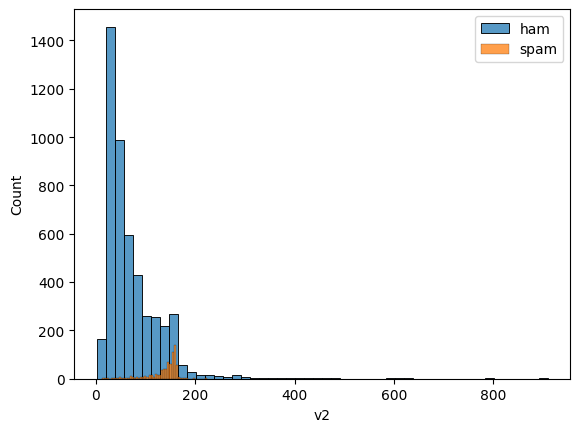

In [ ]:
sns.histplot(df[df["v1"]=="ham"]["v2"].str.len(), label="ham", bins=50)
sns.histplot(df[df["v1"]=="spam"]["v2"].str.len(), label="spam", bins=50)

plt.legend()

#Vemos que hay una tendencia clara a que los mensajes que no son spam son mas pequeños

No hay mucho mas que mirar en general, asi que podemos pasar al preprocesado

In [ ]:
# Saque esta función de https://www.kaggle.com/tanulsingh077 y de https://www.kaggle.com/code/andreshg/nlp-glove-bert-tf-idf-lstm-explained#2.-EDA-%F0%9F%93%8A
# esto lo hacemos porque no vamos a usar transformer, sino con urls seria suficiente
import re
import string
def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    text = str(text).lower()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    text = re.sub('\n', '', text)
    text = re.sub('\w*\d\w*', '', text)
    return text

<>:8: SyntaxWarning: invalid escape sequence '\['
<>:9: SyntaxWarning: invalid escape sequence '\S'
<>:13: SyntaxWarning: invalid escape sequence '\w'
<>:8: SyntaxWarning: invalid escape sequence '\['
<>:9: SyntaxWarning: invalid escape sequence '\S'
<>:13: SyntaxWarning: invalid escape sequence '\w'
C:\Users\usuario\AppData\Local\Temp\ipykernel_7416\1511883570.py:8: SyntaxWarning: invalid escape sequence '\['
  text = re.sub('\[.*?\]', '', text)
C:\Users\usuario\AppData\Local\Temp\ipykernel_7416\1511883570.py:9: SyntaxWarning: invalid escape sequence '\S'
  text = re.sub('https?://\S+|www\.\S+', '', text)
C:\Users\usuario\AppData\Local\Temp\ipykernel_7416\1511883570.py:13: SyntaxWarning: invalid escape sequence '\w'
  text = re.sub('\w*\d\w*', '', text)


por el mimso motivo de no usar nlp moderno, voy a quitar las stopwords, que son palabras como the o is que aportan poco, por no decir nada a nuestros modelos

In [41]:
import sys
!{sys.executable} -m pip install nltk


[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [44]:
import nltk
nltk.download('stopwords')
from nltk.corpus import stopwords
stopwords = stopwords.words('english') + ['u', 'ü', 'ur', '4', '2', 'im', 'dont', 'doin', 'ure']

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\usuario\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [63]:
def eliminarstopwords(texto):
    texto =" ".join(word for word in texto.split(' ') if word not in stopwords)
    return texto

#Con esto definido ya puedo hacer la nueva columna

df['mensaje_normalizado'] = df['v2'].apply(clean_text) 
#ojo que sin apply al no estar vectorizado no se haria a todas

In [64]:
df['mensaje_normalizado'] = df['mensaje_normalizado'].apply(eliminarstopwords)

In [69]:
#como vimos que habia algo de relacion podemos crear tambien el len como feature
df['longitud_mensaje'] = df['mensaje_normalizado'].apply(len)

In [70]:
df

,v1,v2,mensaje_normalizado,longitud_mensaje
0,ham,"Go until jurong point, crazy.. Available only ...",go jurong point crazy available bugis n great ...,82
1,ham,Ok lar... Joking wif u oni...,ok lar joking wif oni,21
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,free entry wkly comp win fa cup final tkts m...,103
3,ham,U dun say so early hor... U c already then say...,dun say early hor c already say,31
4,ham,"Nah I don't think he goes to usf, he lives aro...",nah think goes usf lives around though,38
...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,time tried contact å£ pound prize claim eas...,81
5568,ham,Will Ì_ b going to esplanade fr home?,ì b going esplanade fr home,27
5569,ham,"Pity, * was in mood for that. So...any other s...",pity mood soany suggestions,28
5570,ham,The guy did some bitching but I acted like i'd...,guy bitching acted like id interested buying s...,82


In [75]:
#Ahora para ham y spam podemos usar un label encoder

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['target'] = le.fit_transform(df['v1'])

In [77]:
x = df.mensaje_normalizado
y = df.target

In [78]:
#Partimos en train_test_split

from sklearn.model_selection import train_test_split

xtrain,xtest,ytrain,ytest = train_test_split(x,y, random_state=42)

Vamos a comparar diversos modelos, concretamente NaiveBayes, XGBoost, LSTM y BERT.

En esta primer versión solo esta NaiveBayes, iré actualizándola

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfTransformer
#from sklearn.pipeline import Pipeline no lo voy a usar pero es muy interesante

cv = CountVectorizer(stop_words='english', ngram_range=(1,2),min_df=0.01, max_df=0.7,max_features=100)
xtrain_cv = cv.fit_transform(xtrain)
xtest_cv = cv.transform(xtest)
#he puesto esa configuracion ya que los ngramas pueden mejorar muchos los modelos y tambien filtramos
#por palabras muy raras y muy comunes, asi como un valor maximo para que no crezca mucho por los bigramas
#tf = TfidfTransformer()
#xtrain_tf = tf.fit_transform(xtrain_cv)
#xtest_tf = tf.transform(xtest_cv)

In [124]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

In [125]:
#Entreno el modelo
nb.fit(xtrain_cv,ytrain)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


Ahora vamos a medir que tal lo ha hecho, para ello voy a mostrar la matriz de confusion y la curva pr ya que en clases desbalanceadas como este caso suele ser bastante mejor.

In [126]:
from sklearn.metrics import precision_recall_curve, ConfusionMatrixDisplay

y_pred = nb.predict(xtest_cv)

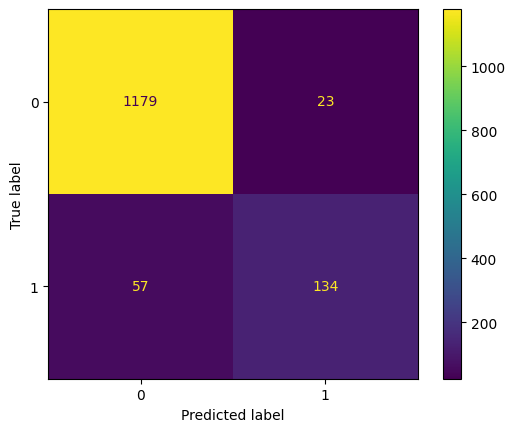

In [127]:
ConfusionMatrixDisplay.from_predictions(ytest,y_pred)

In [128]:
y_scores = nb.predict_proba(xtest_cv)[:,1] #estamos cogiendo la prob de la clase positiva, que es spam

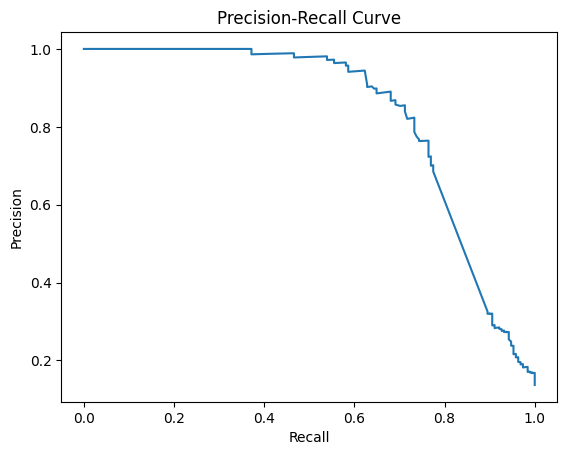

In [129]:
precision, recall, thresholds = precision_recall_curve(ytest, y_scores)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

In [130]:
from sklearn.metrics import average_precision_score

ap = average_precision_score(ytest, y_scores)
print("Average Precision:", ap)

Average Precision: 0.808277437886299


A partir de estos valores se pueden extraer varias conclusiones:

Precisión del modelo

El modelo obtiene una precision aproximada de 0.85, lo que significa que cuando el clasificador predice que un mensaje es spam, en la mayoría de los casos la predicción es correcta. Esto es importante en sistemas de filtrado de spam, ya que un número elevado de falsos positivos implicaría bloquear mensajes legítimos.

Capacidad de detección de spam

El modelo detecta aproximadamente el 70% del spam real (recall ≈ 0.70). Aunque el rendimiento es razonable, todavía existe una proporción de mensajes spam que no son detectados y que pasan como mensajes legítimos.

Rendimiento global

La Average Precision obtenida es aproximadamente 0.81, lo que indica una buena capacidad del modelo para distinguir entre las clases spam y ham. La curva Precision-Recall muestra que el modelo mantiene valores altos de precisión para niveles moderados de recall, lo que sugiere que el clasificador aprende patrones relevantes del lenguaje utilizado en los mensajes spam.

Comportamiento del clasificador

El modelo presenta un comportamiento relativamente equilibrado: mantiene un número bajo de falsos positivos (23) mientras que detecta una proporción significativa de los mensajes spam. Este tipo de comportamiento es adecuado en sistemas de filtrado, donde suele ser preferible evitar bloquear mensajes legítimos incluso si algunos mensajes spam consiguen pasar el filtro.